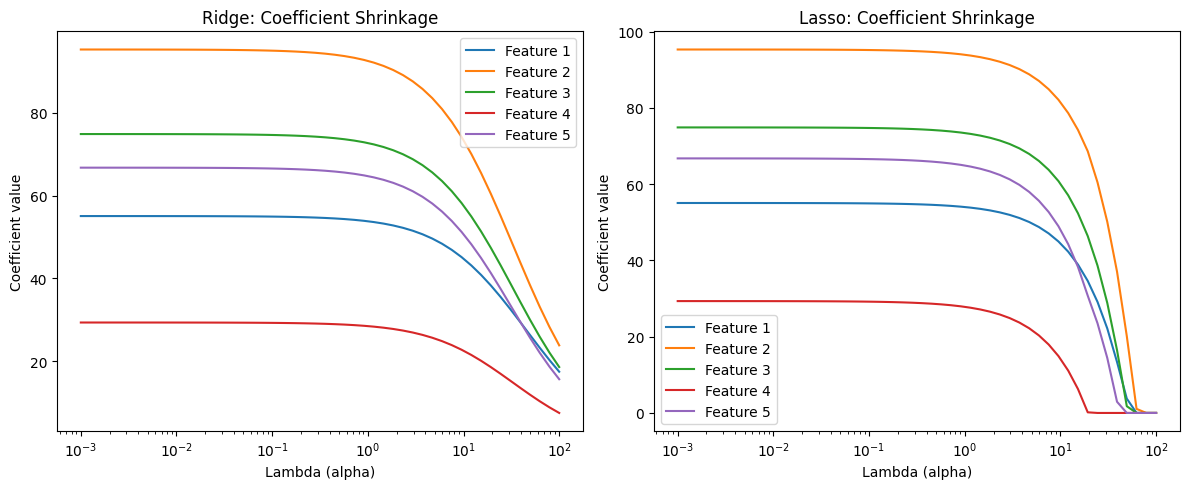

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.linear_model import Ridge, Lasso

# 1. Create a small dataset
X, y = make_regression(n_samples=50, n_features=5, noise=10, random_state=42)

# 2. Range of lambda (alpha) values
lambdas = np.logspace(-3, 2, 50)
coefs_ridge = []
coefs_lasso = []

for l in lambdas:
    ridge = Ridge(alpha=l, fit_intercept=False)
    lasso = Lasso(alpha=l, fit_intercept=False, max_iter=10000)
    ridge.fit(X, y)
    lasso.fit(X, y)
    coefs_ridge.append(ridge.coef_)
    coefs_lasso.append(lasso.coef_)

coefs_ridge = np.array(coefs_ridge)
coefs_lasso = np.array(coefs_lasso)

# 3. Plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for i in range(X.shape[1]):
    plt.plot(lambdas, coefs_ridge[:, i], label=f'Feature {i+1}')
plt.xscale('log')
plt.title('Ridge: Coefficient Shrinkage')
plt.xlabel('Lambda (alpha)')
plt.ylabel('Coefficient value')
plt.legend()

plt.subplot(1, 2, 2)
for i in range(X.shape[1]):
    plt.plot(lambdas, coefs_lasso[:, i], label=f'Feature {i+1}')
plt.xscale('log')
plt.title('Lasso: Coefficient Shrinkage')
plt.xlabel('Lambda (alpha)')
plt.ylabel('Coefficient value')
plt.legend()

plt.tight_layout()
plt.show()
